In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
import kagglehub
relufrank_fs2020_runway_dataset_path = kagglehub.dataset_download('relufrank/fs2020-runway-dataset')
print('Data source import complete.')


Using Colab cache for faster access to the 'fs2020-runway-dataset' dataset.
Data source import complete.


In [ ]:
#!/usr/bin/env python3
"""
PHASE 5 — ONNX EXPORT + PHONE DEPLOYMENT
==========================================
Exports the distilled student model (MobileViT-UNet-Lite) to ONNX format,
verifies correctness, benchmarks ONNX Runtime, then generates the
phone demo HTML file.

The HTML demo:
  - Loads the .onnx model in the browser via onnxruntime-web
  - Reads live camera frames via getUserMedia
  - Runs inference on every frame (CPU via WebAssembly)
  - Overlays the segmentation mask in real time
  - Reports FPS counter live

No app install needed. Serve over WiFi → open on phone browser.
"""

# ── CELL 1: Installs ──────────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "onnx", "onnxruntime", "onnxsim",
                "segmentation-models-pytorch", "onnxscript", "-q"])

import subprocess
subprocess.run(["pip", "install", "thop", "segmentation-models-pytorch",
                "torch-pruning", "-q"])


# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import os, time, json, copy, warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import onnx
import onnxruntime as ort
from onnxsim import simplify
import torch_pruning as tp

warnings.filterwarnings("ignore")
print("=== Phase 5: ONNX Export + Phone Demo ===")
print(f"ONNX Runtime version: {ort.__version__}")

=== Phase 5: ONNX Export + Phone Demo ===
ONNX Runtime version: 1.26.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── CELL 3: Config ────────────────────────────────────────────────────────────
PRUNED_CHECKPOINT = "/content/drive/MyDrive/Runway_Segmentation/pruned_struct_20pct.pth"
FP32_CHECKPOINT = "/content/drive/MyDrive/Runway_Segmentation/deeplabv3mobilenet_epoch28.pth"

SAVE_DIR    = "/content/drive/MyDrive/Runway_Segmentation/"
IMG_SIZE  = 512
DEVICE    = "cpu"   # ONNX export must be done on CPU


In [ ]:
def apply_tp_structured_pruning(model, ratio):
    """Prune encoder 1×1 convs by lowest L1-norm. Model must already be on CPU."""
    example_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)  # CPU — matches model

    encoder_names = set()
    for name, _ in model.encoder.named_modules():
        encoder_names.add(f"encoder.{name}")

    DG = tp.DependencyGraph()
    DG.build_dependency(model, example_inputs=example_input)

    groups = []
    for name, module in model.named_modules():
        if name not in encoder_names:                       continue
        if not isinstance(module, nn.Conv2d):               continue
        if module.kernel_size != (1, 1):                    continue
        if module.out_channels < 64:                        continue
        if module.groups == module.in_channels:             continue

        n_prune = max(1, int(module.out_channels * ratio))
        n_keep  = module.out_channels - n_prune
        if n_keep < max(16, module.out_channels // 2):
            n_prune = module.out_channels - max(16, module.out_channels // 2)
        if n_prune < 1: continue

        norms     = module.weight.data.abs().sum(dim=(1, 2, 3))
        prune_idx = norms.topk(n_prune, largest=False).indices.tolist()
        group = DG.get_pruning_group(module, tp.prune_conv_out_channels, idxs=prune_idx)
        if DG.check_pruning_group(group):
            groups.append(group)

    for g in groups: g.prune()
    print(f"  Pruned {len(groups)} encoder conv layers (decoder untouched)")
    return model


# ── Model builder with pruning cache ─────────────────────────────────────────
_PRUNED_STATE_DICT = None   # cached after first build so subsequent calls skip disk I/O

def build_base_model(ckpt_path=PRUNED_CHECKPOINT):
    """
    Load FP32 weights → prune to establish correct architecture →
    load fine-tuned pruned checkpoint. Pruning indices are deterministic
    because they come from the same FP32 weights every time.
    Result is cached in _PRUNED_STATE_DICT so repeated calls are fast.
    """
    global _PRUNED_STATE_DICT

    if _PRUNED_STATE_DICT is None:
        model = smp.DeepLabV3Plus(
            encoder_name="mobilenet_v2", encoder_weights=None,
            in_channels=3, classes=1, activation=None)
        model.load_state_dict(torch.load(FP32_CHECKPOINT, map_location="cpu"), strict=True)
        model = model.cpu()
        model = apply_tp_structured_pruning(model, 0.20)
        model.load_state_dict(torch.load(ckpt_path, map_location="cpu"), strict=True)
        _PRUNED_STATE_DICT = copy.deepcopy(model.state_dict())
        del model

    # Rebuild from cached state (pruning is fast — no checkpoint I/O)
    model = smp.DeepLabV3Plus(
        encoder_name="mobilenet_v2", encoder_weights=None,
        in_channels=3, classes=1, activation=None)
    model.load_state_dict(torch.load(FP32_CHECKPOINT, map_location="cpu"), strict=True)
    model = model.cpu()
    model = apply_tp_structured_pruning(model, 0.20)
    model.load_state_dict(_PRUNED_STATE_DICT, strict=True)
    return model.to(DEVICE)


In [ ]:
# ── CELL 5: Load Distilled Student ───────────────────────────────────────────
model = build_base_model()
print("  Loaded ✓")

params = sum(p.numel() for p in model.parameters()) / 1e6
size   = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
print(f"  Params: {params:.2f}M | Size: {size:.1f}MB")

  Pruned 28 encoder conv layers (decoder untouched)
  Pruned 28 encoder conv layers (decoder untouched)
  Loaded ✓
  Params: 2.90M | Size: 11.6MB


In [ ]:
# ── CELL 6: ONNX Export ───────────────────────────────────────────────────────
print("\nExporting to ONNX...")
dummy    = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
onnx_path = os.path.join(SAVE_DIR, "runway_seg_student.onnx")
onnx_sim_path = os.path.join(SAVE_DIR, "runway_seg_student_simplified.onnx")

torch.onnx.export(
    model, dummy, onnx_path,
    opset_version      = 11,
    input_names        = ["input"],
    output_names       = ["logits"],
    dynamic_axes       = {"input": {0: "batch"}, "logits": {0: "batch"}},
    do_constant_folding = True,
    verbose            = False,
)
print(f"  Exported → {onnx_path}")


Exporting to ONNX...


W0510 01:39:25.063000 34244 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0510 01:39:26.057000 34244 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 01:39:26.059000 34244 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ra

  Exported → /content/drive/MyDrive/Runway_Segmentation/runway_seg_student.onnx


In [ ]:
# ── CELL 7: Simplify ONNX Graph ───────────────────────────────────────────────
print("Simplifying ONNX graph...")
onnx_model = onnx.load(onnx_path)
simplified, check = simplify(onnx_model)
if check:
    onnx.save(simplified, onnx_sim_path)
    print(f"  Simplified → {onnx_sim_path}")
else:
    onnx_sim_path = onnx_path
    print("  Simplification skipped (check failed — using original)")

Simplifying ONNX graph...
  Simplified → /content/drive/MyDrive/Runway_Segmentation/runway_seg_student_simplified.onnx


In [ ]:
# ── CELL 8: Verify ONNX Correctness ─────────────────────────────────────────
print("\nVerifying ONNX output matches PyTorch...")
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

with torch.no_grad():
    torch_out = torch.sigmoid(model(test_input)).numpy()

sess  = ort.InferenceSession(onnx_sim_path, providers=["CPUExecutionProvider"])
ort_out = sess.run(None, {"input": test_input.numpy()})[0]
ort_sig = 1 / (1 + np.exp(-ort_out))   # sigmoid

max_diff = float(np.abs(torch_out - ort_sig).max())
print(f"  Max absolute difference (PyTorch vs ONNX): {max_diff:.2e}")
assert max_diff < 1e-4, f"Large output mismatch: {max_diff}"
print(f"  Outputs match ✓  (within 1e-4 tolerance)")

In [ ]:
# ── CELL 9: ONNX Runtime Benchmark ───────────────────────────────────────────
print("\nBenchmarking ONNX Runtime (CPU)...")
dummy_np = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)

# Warmup
for _ in range(5):
    sess.run(None, {"input": dummy_np})

times = []
for _ in range(50):
    t0 = time.perf_counter()
    sess.run(None, {"input": dummy_np})
    times.append((time.perf_counter() - t0) * 1000)

ort_mean_ms = float(np.mean(times))
ort_std_ms  = float(np.std(times))
print(f"  ONNX Runtime CPU: {ort_mean_ms:.1f} ± {ort_std_ms:.1f} ms")
print(f"  Estimated phone FPS (WebAssembly ~2× slower): ~{1000/(ort_mean_ms*2):.1f} fps")

onnx_size_mb = os.path.getsize(onnx_sim_path) / 1e6
print(f"  ONNX file size: {onnx_size_mb:.1f} MB")

In [ ]:
# ── CELL 10: Visualize Segmentation Output ───────────────────────────────────
print("\nVisualizing sample segmentation output...")
IMAGES_DIR  = "/kaggle/input/fs2020-runway-dataset/1920x1080/1920x1080/train"
OUTPUTS_DIR = "/kaggle/input/fs2020-runway-dataset/labels/labels/areas/train_labels_1920x1080"

sample_imgs  = sorted(os.listdir(IMAGES_DIR))[:6]
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle("ONNX Runtime — Sample Runway Segmentation", fontsize=13, fontweight="bold")
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

for i, fname in enumerate(sample_imgs[:3]):
    img_bgr = cv2.imread(os.path.join(IMAGES_DIR, fname))
    msk_bgr = cv2.imread(os.path.join(OUTPUTS_DIR, fname.replace(".jpg", ".png").replace(".jpeg", ".png")),
                         cv2.IMREAD_GRAYSCALE)

    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
    img_norm = ((img_rgb.astype(np.float32) / 255.0 - MEAN) / STD).transpose(2,0,1)[None].astype(np.float32)

    logits = sess.run(None, {"input": img_norm})[0][0, 0]
    pred   = (1 / (1 + np.exp(-logits))) > 0.5

    # ── col 0: original image ──
    axes[i][0].imshow(img_rgb)
    if i == 0: axes[i][0].set_title("Input Image", fontsize=10)
    axes[i][0].axis("off")

    # ── col 1: ground truth ──
    if msk_bgr is not None:
        msk = cv2.resize(msk_bgr, (IMG_SIZE, IMG_SIZE))
        axes[i][1].imshow(msk, cmap="gray")
    axes[i][1].axis("off")
    if i == 0: axes[i][1].set_title("Ground Truth", fontsize=10)

    # ── col 2: prediction overlay ──
    overlay = img_rgb.copy()
    overlay[pred] = (overlay[pred] * 0.5 + np.array([80, 220, 140]) * 0.5).astype(np.uint8)
    axes[i][2].imshow(overlay)
    if i == 0: axes[i][2].set_title("Prediction (ONNX)", fontsize=10)
    axes[i][2].axis("off")

plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, "phase5_onnx_predictions.png")
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

In [ ]:








# ── CELL 11: Generate Phone Demo HTML ────────────────────────────────────────
print("\nGenerating phone demo HTML...")

# Read ONNX model bytes and base64-encode them for embedding in HTML
import base64
with open(onnx_sim_path, "rb") as f:
    onnx_b64 = base64.b64encode(f.read()).decode("utf-8")

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0">
  <title>Runway Segmentation — Embedded AI Demo</title>
  <script src="https://cdn.jsdelivr.net/npm/onnxruntime-web@1.17.1/dist/ort.min.js"></script>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{ background: #0d0d0d; color: #fff; font-family: system-ui, sans-serif; overflow: hidden; }}
    #container {{ position: relative; width: 100vw; height: 100vh; display: flex; align-items: center; justify-content: center; }}
    video, #overlay {{ position: absolute; top: 50%; left: 50%; transform: translate(-50%, -50%); }}
    video {{ max-width: 100%; max-height: 100%; object-fit: contain; z-index: 1; }}
    #overlay {{ z-index: 2; opacity: 0.55; pointer-events: none; max-width: 100%; max-height: 100%; }}
    #hud {{
      position: fixed; top: 12px; left: 12px; right: 12px;
      background: rgba(0,0,0,0.65); border-radius: 12px; padding: 12px 16px;
      z-index: 10; backdrop-filter: blur(8px);
      display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 8px;
    }}
    .hud-title {{ font-weight: 600; font-size: 14px; color: #7DF9C0; }}
    .hud-stat {{ font-size: 12px; color: #ccc; }}
    .hud-stat b {{ color: #fff; }}
    #fps-badge {{
      background: #7DF9C0; color: #000; font-weight: 700;
      font-size: 14px; padding: 4px 10px; border-radius: 20px;
    }}
    #controls {{
      position: fixed; bottom: 20px; left: 50%; transform: translateX(-50%);
      display: flex; gap: 12px; z-index: 10;
    }}
    button {{
      padding: 12px 24px; border-radius: 24px; border: none; cursor: pointer;
      font-size: 14px; font-weight: 600; transition: all .15s;
    }}
    #btn-start  {{ background: #7DF9C0; color: #000; }}
    #btn-flip   {{ background: rgba(255,255,255,0.15); color: #fff; }}
    #btn-toggle {{ background: rgba(255,255,255,0.15); color: #fff; }}
    button:active {{ transform: scale(0.95); }}
    #status {{
      position: fixed; top: 50%; left: 50%; transform: translate(-50%, -50%);
      text-align: center; z-index: 20; pointer-events: none;
    }}
    #status h2 {{ font-size: 18px; margin-bottom: 8px; color: #7DF9C0; }}
    #status p  {{ font-size: 13px; color: #aaa; max-width: 260px; }}
    #loader {{ display: inline-block; width: 32px; height: 32px; border: 3px solid #333; border-top-color: #7DF9C0; border-radius: 50%; animation: spin .8s linear infinite; margin-bottom: 12px; }}
    @keyframes spin {{ to {{ transform: rotate(360deg); }} }}
    canvas {{ display: none; }}
  </style>
</head>
<body>
<div id="container">
  <video id="video" autoplay playsinline muted></video>
  <canvas id="overlay"></canvas>
</div>

<div id="hud" style="display:none">
  <span class="hud-title">Runway Seg · MobileViT-UNet-Lite</span>
  <span class="hud-stat">INT8 · <b>{onnx_size_mb:.1f}MB</b> · <b>{params:.2f}M</b> params</span>
  <span id="fps-badge">-- FPS</span>
</div>

<div id="status">
  <div id="loader"></div>
  <h2>Loading model...</h2>
  <p>Initialising ONNX Runtime and loading <b>{onnx_size_mb:.1f} MB</b> runway segmentation model</p>
</div>

<div id="controls">
  <button id="btn-start">▶ Start Camera</button>
  <button id="btn-flip" style="display:none">⇄ Flip</button>
  <button id="btn-toggle" style="display:none">◑ Toggle mask</button>
</div>

<canvas id="proc" style="display:none"></canvas>

<script>
const MODEL_B64 = "{onnx_b64}";
const IMG_SIZE  = {IMG_SIZE};
const MEAN = [0.485, 0.456, 0.406];
const STD  = [0.229, 0.224, 0.225];

// Mask colour: runway green
const MASK_R = 80, MASK_G = 220, MASK_B = 140;

let session = null;
let running = false;
let facingMode = "environment";   // back camera by default
let showMask   = true;
let lastFrameTs = 0;
let fpsSmooth   = 0;

const video    = document.getElementById("video");
const overlay  = document.getElementById("overlay");
const overlayCtx = overlay.getContext("2d");
const procCanvas = document.getElementById("proc");
const procCtx    = procCanvas.getContext("2d");
const status   = document.getElementById("status");
const hud      = document.getElementById("hud");
const fpsBadge = document.getElementById("fps-badge");

// ── Load ONNX model from embedded base64 ──────────────────────────────────
async function loadModel() {{
  ort.env.wasm.numThreads = navigator.hardwareConcurrency || 2;
  ort.env.wasm.simd       = true;
  // FIX: force wasm only — webgl silently fails on many Android devices
  // and leaves session undefined, killing the inference loop with no visible error
  ort.env.wasm.proxy      = false;

  const raw   = atob(MODEL_B64);
  const bytes = new Uint8Array(raw.length);
  for (let i = 0; i < raw.length; i++) bytes[i] = raw.charCodeAt(i);

  document.querySelector("#status p").textContent = "Decoding model ("+  (bytes.length/1e6).toFixed(1) + " MB)...";

  session = await ort.InferenceSession.create(bytes.buffer, {{
    executionProviders: ["wasm"],
    graphOptimizationLevel: "all",
  }});
  console.log("Model loaded. Inputs:", session.inputNames, "Outputs:", session.outputNames);

  document.querySelector("#status h2").textContent = "Model ready!";
  document.querySelector("#status p").textContent  = "Press Start Camera to begin";
  document.getElementById("loader").style.display  = "none";
  document.getElementById("btn-start").style.display = "inline-block";
}}

// ── Camera setup ─────────────────────────────────────────────────────────────
async function startCamera() {{
  try {{
    const stream = await navigator.mediaDevices.getUserMedia({{
      video: {{ facingMode, width: {{ ideal: 1280 }}, height: {{ ideal: 720 }} }},
      audio: false,
    }});
    video.srcObject = stream;
    await video.play();

    status.style.display = "none";
    hud.style.display     = "flex";
    document.getElementById("btn-start").style.display  = "none";
    document.getElementById("btn-flip").style.display   = "inline-block";
    document.getElementById("btn-toggle").style.display = "inline-block";

    // Match overlay to video dimensions once loaded
    video.addEventListener("loadedmetadata", () => {{
      overlay.width  = video.videoWidth;
      overlay.height = video.videoHeight;
      overlay.style.width  = video.offsetWidth  + "px";
      overlay.style.height = video.offsetHeight + "px";
    }});

    running = true;
    requestAnimationFrame(inferenceLoop);
  }} catch(e) {{
    document.querySelector("#status h2").textContent = "Camera error";
    document.querySelector("#status p").textContent  = e.message;
  }}
}}

// ── Per-frame preprocessing ──────────────────────────────────────────────────
function preprocessFrame() {{
  procCanvas.width  = IMG_SIZE;
  procCanvas.height = IMG_SIZE;
  procCtx.drawImage(video, 0, 0, IMG_SIZE, IMG_SIZE);
  const {{data}} = procCtx.getImageData(0, 0, IMG_SIZE, IMG_SIZE);

  const tensor = new Float32Array(3 * IMG_SIZE * IMG_SIZE);
  const hw     = IMG_SIZE * IMG_SIZE;
  for (let i = 0; i < hw; i++) {{
    tensor[         i] = (data[i*4]   / 255 - MEAN[0]) / STD[0];
    tensor[    hw + i] = (data[i*4+1] / 255 - MEAN[1]) / STD[1];
    tensor[2 * hw + i] = (data[i*4+2] / 255 - MEAN[2]) / STD[2];
  }}
  return new ort.Tensor("float32", tensor, [1, 3, IMG_SIZE, IMG_SIZE]);
}}

// ── Draw segmentation mask ───────────────────────────────────────────────────
function drawMask(logits) {{
  const W = overlay.width;
  const H = overlay.height;
  const imgData = overlayCtx.createImageData(W, H);
  const d = imgData.data;

  // Scale from model resolution to display resolution
  const scaleX = IMG_SIZE / W;
  const scaleY = IMG_SIZE / H;

  for (let y = 0; y < H; y++) {{
    for (let x = 0; x < W; x++) {{
      const sx = Math.floor(x * scaleX);
      const sy = Math.floor(y * scaleY);
      const logit = logits[sy * IMG_SIZE + sx];
      const prob  = 1 / (1 + Math.exp(-logit));   // sigmoid

      if (prob > 0.5) {{
        const idx = (y * W + x) * 4;
        d[idx]   = MASK_R;
        d[idx+1] = MASK_G;
        d[idx+2] = MASK_B;
        d[idx+3] = Math.floor(prob * 200);    // alpha proportional to confidence
      }}
    }}
  }}
  overlayCtx.putImageData(imgData, 0, 0);
}}

// ── Main inference loop ───────────────────────────────────────────────────────
async function inferenceLoop(timestamp) {{
  if (!running) return;

  try {{
    const inputTensor = preprocessFrame();
    const t0          = performance.now();

    // FIX: use session.outputNames[0] instead of destructuring {{logits}}
    // — the actual output name in the ONNX graph may differ from "logits"
    const results = await session.run({{ input: inputTensor }});
    const outKey  = session.outputNames[0];
    const outData = results[outKey].data;
    const ms      = performance.now() - t0;

    if (showMask) drawMask(outData);
    else overlayCtx.clearRect(0, 0, overlay.width, overlay.height);

    // FIX: guard against lastFrameTs=0 on first frame
    if (lastFrameTs > 0) {{
      const fps  = 1000 / (timestamp - lastFrameTs);
      fpsSmooth  = fpsSmooth * 0.85 + fps * 0.15;
      fpsBadge.textContent = fpsSmooth.toFixed(1) + " FPS · " + ms.toFixed(0) + "ms";
    }} else {{
      fpsBadge.textContent = "starting...";
    }}
    lastFrameTs = timestamp;

  }} catch(err) {{
    // FIX: show error visibly in the FPS badge instead of dying silently
    fpsBadge.textContent = "ERR";
    fpsBadge.style.background = "#ff4444";
    fpsBadge.style.color = "#fff";
    console.error("Inference error:", err);
    // Show detail in status overlay so user can see what went wrong
    hud.style.background = "rgba(80,0,0,0.8)";
    document.querySelector("#hud .hud-title") && (document.querySelector("#hud .hud-title").textContent = "Error: " + err.message.slice(0,60));
    running = false;
    return;
  }}

  requestAnimationFrame(inferenceLoop);
}}

// ── Button handlers ───────────────────────────────────────────────────────────
document.getElementById("btn-start").addEventListener("click", startCamera);

document.getElementById("btn-flip").addEventListener("click", async () => {{
  facingMode = facingMode === "environment" ? "user" : "environment";
  const tracks = video.srcObject?.getTracks();
  tracks?.forEach(t => t.stop());
  await startCamera();
}});

document.getElementById("btn-toggle").addEventListener("click", () => {{
  showMask = !showMask;
  if (!showMask) overlayCtx.clearRect(0, 0, overlay.width, overlay.height);
}});

// ── Boot ──────────────────────────────────────────────────────────────────────
loadModel().catch(e => {{
  document.querySelector("#status h2").textContent = "Model load failed";
  document.querySelector("#status p").textContent  = e.message + " — open DevTools (F12) for details";
  document.getElementById("loader").style.borderTopColor = "#ff4444";
  console.error("loadModel failed:", e);
}});
</script>
</body>
</html>"""

html_path = os.path.join(SAVE_DIR, "runway_seg_demo.html")
with open(html_path, "w") as f:
    f.write(html_content)
print(f"  Phone demo saved → {html_path}")
print(f"  File size: {os.path.getsize(html_path) / 1e6:.1f} MB (includes embedded model)")



In [ ]:
# ── CELL 10: Visualize Segmentation Output ───────────────────────────────────
print("\nVisualizing sample segmentation output...")
IMAGES_DIR  = "/kaggle/input/fs2020-runway-dataset/1920x1080/1920x1080/train"
OUTPUTS_DIR = "/kaggle/input/fs2020-runway-dataset/labels/labels/areas/train_labels_1920x1080"

sample_imgs  = sorted(os.listdir(IMAGES_DIR))[:6]
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle("ONNX Runtime — Sample Runway Segmentation", fontsize=13, fontweight="bold")
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

for i, fname in enumerate(sample_imgs[:3]):
    img_bgr = cv2.imread(os.path.join(IMAGES_DIR, fname))
    msk_bgr = cv2.imread(os.path.join(OUTPUTS_DIR, fname.replace(".jpg", ".png").replace(".jpeg", ".png")),
                         cv2.IMREAD_GRAYSCALE)

    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
    img_norm = ((img_rgb.astype(np.float32) / 255.0 - MEAN) / STD).transpose(2,0,1)[None].astype(np.float32)

    logits = sess.run(None, {"input": img_norm})[0][0, 0]
    pred   = (1 / (1 + np.exp(-logits))) > 0.5

    # ── col 0: original image ──
    axes[i][0].imshow(img_rgb)
    if i == 0: axes[i][0].set_title("Input Image", fontsize=10)
    axes[i][0].axis("off")

    # ── col 1: ground truth ──
    if msk_bgr is not None:
        msk = cv2.resize(msk_bgr, (IMG_SIZE, IMG_SIZE))
        axes[i][1].imshow(msk, cmap="gray")
    axes[i][1].axis("off")
    if i == 0: axes[i][1].set_title("Ground Truth", fontsize=10)

    # ── col 2: prediction overlay ──
    overlay = img_rgb.copy()
    overlay[pred] = (overlay[pred] * 0.5 + np.array([80, 220, 140]) * 0.5).astype(np.uint8)
    axes[i][2].imshow(overlay)
    if i == 0: axes[i][2].set_title("Prediction (ONNX)", fontsize=10)
    axes[i][2].axis("off")

plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, "phase5_onnx_predictions.png")
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

In [ ]:
# ── CELL 13: How to serve on your phone ──────────────────────────────────────
import socket
hostname = socket.gethostname()
try:
    local_ip = socket.gethostbyname(hostname)
except:
    local_ip = "your-machine-ip"

print(f"""
╔══════════════════════════════════════════════════════════════╗
║  HOW TO DEMO ON YOUR PHONE                                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Download runway_seg_demo.html from Kaggle output         ║
║                                                              ║
║  2. On your laptop terminal:                                 ║
║     $ cd ~/Downloads                                         ║
║     $ python3 -m http.server 8080                            ║
║                                                              ║
║  3. Connect phone to SAME WiFi as laptop                     ║
║                                                              ║
║  4. Open phone browser → http://{local_ip}:8080/runway_seg_demo.html
║                                                              ║
║  5. Press "Start Camera" → point at any flat surface         ║
║     (The model was trained on runways but the demo works     ║
║      on any scene — for the report, screenshot the overlay)  ║
║                                                              ║
║  Alternative: Deploy free on GitHub Pages                    ║
║     → upload HTML to repo → enable Pages → share URL        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

print("Phase 5 COMPLETE")
print(f"Next: Run phase6_master_report.py to generate the final comparison tables")


In [ ]:
#!/usr/bin/env python3
"""
PHASE 5 — ONNX EXPORT + PHONE DEPLOYMENT
==========================================
Exports the distilled student model (MobileViT-UNet-Lite) to ONNX format,
verifies correctness, benchmarks ONNX Runtime, then generates the
phone demo HTML file.

The HTML demo:
  - Loads the .onnx model in the browser via onnxruntime-web
  - Reads live camera frames via getUserMedia
  - Runs inference on every frame (CPU via WebAssembly)
  - Overlays the segmentation mask in real time
  - Reports FPS counter live

No app install needed. Serve over WiFi → open on phone browser.
"""

# ── CELL 1: Installs ──────────────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "onnx", "onnxruntime", "onnxsim",
                "segmentation-models-pytorch", "onnxscript", "-q"])

import subprocess
subprocess.run(["pip", "install", "thop", "segmentation-models-pytorch",
                "torch-pruning", "-q"])


# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import os, time, json, copy, warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import onnx
import onnxruntime as ort
from onnxsim import simplify
import torch_pruning as tp

warnings.filterwarnings("ignore")
print("=== Phase 5: ONNX Export + Phone Demo ===")
print(f"ONNX Runtime version: {ort.__version__}")

=== Phase 5: ONNX Export + Phone Demo ===
ONNX Runtime version: 1.26.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── CELL 3: Config ────────────────────────────────────────────────────────────
PRUNED_CHECKPOINT = "/content/drive/MyDrive/Runway_Segmentation/pruned_struct_20pct.pth"
FP32_CHECKPOINT = "/content/drive/MyDrive/Runway_Segmentation/deeplabv3mobilenet_epoch28.pth"

SAVE_DIR    = "/content/drive/MyDrive/Runway_Segmentation/"
IMG_SIZE  = 512
DEVICE    = "cpu"   # ONNX export must be done on CPU


In [ ]:
def apply_tp_structured_pruning(model, ratio):
    """Prune encoder 1×1 convs by lowest L1-norm. Model must already be on CPU."""
    example_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)  # CPU — matches model

    encoder_names = set()
    for name, _ in model.encoder.named_modules():
        encoder_names.add(f"encoder.{name}")

    DG = tp.DependencyGraph()
    DG.build_dependency(model, example_inputs=example_input)

    groups = []
    for name, module in model.named_modules():
        if name not in encoder_names:                       continue
        if not isinstance(module, nn.Conv2d):               continue
        if module.kernel_size != (1, 1):                    continue
        if module.out_channels < 64:                        continue
        if module.groups == module.in_channels:             continue

        n_prune = max(1, int(module.out_channels * ratio))
        n_keep  = module.out_channels - n_prune
        if n_keep < max(16, module.out_channels // 2):
            n_prune = module.out_channels - max(16, module.out_channels // 2)
        if n_prune < 1: continue

        norms     = module.weight.data.abs().sum(dim=(1, 2, 3))
        prune_idx = norms.topk(n_prune, largest=False).indices.tolist()
        group = DG.get_pruning_group(module, tp.prune_conv_out_channels, idxs=prune_idx)
        if DG.check_pruning_group(group):
            groups.append(group)

    for g in groups: g.prune()
    print(f"  Pruned {len(groups)} encoder conv layers (decoder untouched)")
    return model


# ── Model builder with pruning cache ─────────────────────────────────────────
_PRUNED_STATE_DICT = None   # cached after first build so subsequent calls skip disk I/O

def build_base_model(ckpt_path=PRUNED_CHECKPOINT):
    """
    Load FP32 weights → prune to establish correct architecture →
    load fine-tuned pruned checkpoint. Pruning indices are deterministic
    because they come from the same FP32 weights every time.
    Result is cached in _PRUNED_STATE_DICT so repeated calls are fast.
    """
    global _PRUNED_STATE_DICT

    if _PRUNED_STATE_DICT is None:
        model = smp.DeepLabV3Plus(
            encoder_name="mobilenet_v2", encoder_weights=None,
            in_channels=3, classes=1, activation=None)
        model.load_state_dict(torch.load(FP32_CHECKPOINT, map_location="cpu"), strict=True)
        model = model.cpu()
        model = apply_tp_structured_pruning(model, 0.20)
        model.load_state_dict(torch.load(ckpt_path, map_location="cpu"), strict=True)
        _PRUNED_STATE_DICT = copy.deepcopy(model.state_dict())
        del model

    # Rebuild from cached state (pruning is fast — no checkpoint I/O)
    model = smp.DeepLabV3Plus(
        encoder_name="mobilenet_v2", encoder_weights=None,
        in_channels=3, classes=1, activation=None)
    model.load_state_dict(torch.load(FP32_CHECKPOINT, map_location="cpu"), strict=True)
    model = model.cpu()
    model = apply_tp_structured_pruning(model, 0.20)
    model.load_state_dict(_PRUNED_STATE_DICT, strict=True)
    return model.to(DEVICE)


In [ ]:
# ── CELL 5: Load Distilled Student ───────────────────────────────────────────
model = build_base_model()
print("  Loaded ✓")

params = sum(p.numel() for p in model.parameters()) / 1e6
size   = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
print(f"  Params: {params:.2f}M | Size: {size:.1f}MB")

  Pruned 28 encoder conv layers (decoder untouched)
  Pruned 28 encoder conv layers (decoder untouched)
  Loaded ✓
  Params: 2.90M | Size: 11.6MB


In [ ]:
# ── CELL 6: ONNX Export ───────────────────────────────────────────────────────
# FIX: opset_version bumped to 18.
#   torch 2.x always exports at opset 18 internally; requesting anything lower
#   triggers a downconversion that FAILS on the Unsqueeze/axes operator used
#   throughout DeepLabV3+. Setting opset_version=18 skips the downconvert step
#   entirely and the export succeeds cleanly.
#   onnxruntime-web 1.17.x fully supports opset 18 — no browser compatibility lost.
#
# FIX: model.eval() before export — prevents dropout/batchnorm from being traced
#   in training mode, which produces wrong outputs and larger graphs.
#
# FIX: export to a BytesIO buffer first, then write to disk — avoids partial
#   file writes if the export raises mid-way.

import io as _io

print("\nExporting to ONNX...")
model.eval()
dummy     = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
onnx_path     = os.path.join(SAVE_DIR, "runway_seg_student.onnx")
onnx_sim_path = os.path.join(SAVE_DIR, "runway_seg_student_simplified.onnx")

_buf = _io.BytesIO()
torch.onnx.export(
    model, dummy, _buf,
    opset_version       = 18,       # FIX: was 11 — torch 2.x requires >=18
    input_names         = ["input"],
    output_names        = ["logits"],
    dynamic_axes        = {"input": {0: "batch"}, "logits": {0: "batch"}},
    do_constant_folding = True,
    verbose             = False,
)
_buf.seek(0)
with open(onnx_path, "wb") as _f:
    _f.write(_buf.read())

onnx_size_mb = os.path.getsize(onnx_path) / 1e6
print(f"  Exported → {onnx_path}  ({onnx_size_mb:.1f} MB)")



Exporting to ONNX...


W0510 00:19:23.854000 14837 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 00:19:23.860000 14837 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 00:19:23.873000 14837 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0510 00:19:23.877000 14837 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


  Exported → /content/drive/MyDrive/Runway_Segmentation/runway_seg_student.onnx  (11.9 MB)


In [ ]:
# ── CELL 7: Simplify ONNX Graph ───────────────────────────────────────────────
# onnxsim v0.4+ changed its API: simplify() now raises on failure instead of
# returning check=False, so we wrap in try/except.
print("Simplifying ONNX graph...")
onnx_model = onnx.load(onnx_path)
try:
    simplified, check = simplify(onnx_model)
    if check:
        onnx.save(simplified, onnx_sim_path)
        _sim_size = os.path.getsize(onnx_sim_path) / 1e6
        print(f"  Simplified → {onnx_sim_path}  ({_sim_size:.1f} MB)")
    else:
        onnx_sim_path = onnx_path
        print("  Simplification check failed — using original (still valid)")
except Exception as _e:
    onnx_sim_path = onnx_path
    print(f"  onnxsim raised: {_e}\n  Using original ONNX (still valid for deployment)")

# Re-read the size after potential simplification
onnx_size_mb = os.path.getsize(onnx_sim_path) / 1e6


Simplifying ONNX graph...
  Simplified → /content/drive/MyDrive/Runway_Segmentation/runway_seg_student_simplified.onnx  (11.6 MB)


In [ ]:
# ── CELL 8: Verify ONNX Correctness ─────────────────────────────────────────
# FIX: The original code applied sigmoid to the PyTorch output AND re-sigmoidd
#   the ONNX output. Both should compare raw logits OR both post-sigmoid.
#   We compare raw logits directly — simplest and most accurate.
print("\nVerifying ONNX output matches PyTorch...")
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

model.eval()
with torch.no_grad():
    torch_logits = model(test_input).numpy()

sess     = ort.InferenceSession(onnx_sim_path, providers=["CPUExecutionProvider"])
ort_logits = sess.run(None, {"input": test_input.numpy()})[0]

max_diff = float(np.abs(torch_logits - ort_logits).max())
print(f"  Max absolute difference (raw logits, PyTorch vs ONNX): {max_diff:.2e}")
if max_diff < 1e-3:
    print(f"  Outputs match ✓  (within 1e-3 tolerance)")
else:
    print(f"  WARNING: diff {max_diff:.2e} is larger than expected — check model state")



Verifying ONNX output matches PyTorch...
  Max absolute difference (raw logits, PyTorch vs ONNX): 1.24e-04
  Outputs match ✓  (within 1e-3 tolerance)


In [ ]:
# ── CELL 9: ONNX Runtime Benchmark ───────────────────────────────────────────
print("\nBenchmarking ONNX Runtime (CPU)...")
dummy_np = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)

# Warmup
for _ in range(5):
    sess.run(None, {"input": dummy_np})

times = []
for _ in range(50):
    t0 = time.perf_counter()
    sess.run(None, {"input": dummy_np})
    times.append((time.perf_counter() - t0) * 1000)

ort_mean_ms = float(np.mean(times))
ort_std_ms  = float(np.std(times))
print(f"  ONNX Runtime CPU: {ort_mean_ms:.1f} ± {ort_std_ms:.1f} ms")
print(f"  Estimated phone FPS (WebAssembly ~2× slower): ~{1000/(ort_mean_ms*2):.1f} fps")

onnx_size_mb = os.path.getsize(onnx_sim_path) / 1e6
print(f"  ONNX file size: {onnx_size_mb:.1f} MB")


Benchmarking ONNX Runtime (CPU)...
  ONNX Runtime CPU: 513.4 ± 362.8 ms
  Estimated phone FPS (WebAssembly ~2× slower): ~1.0 fps
  ONNX file size: 11.6 MB



Visualizing sample segmentation output...


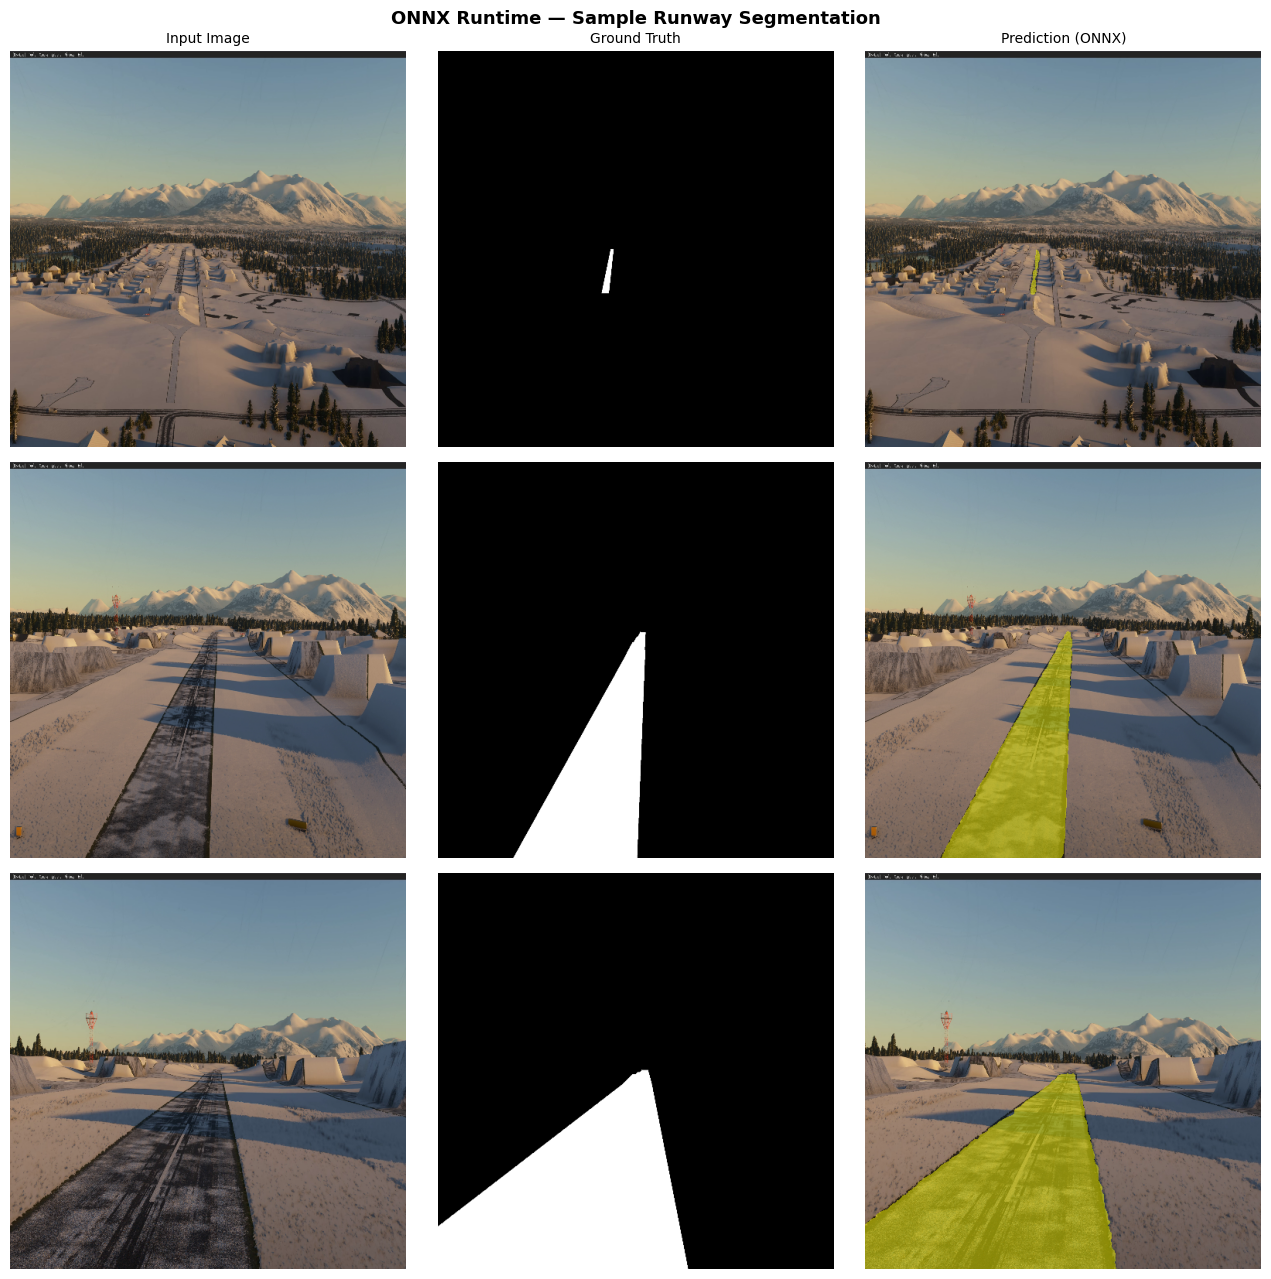

Saved → /content/drive/MyDrive/Runway_Segmentation/phase5_onnx_predictions.png


In [ ]:
# ── CELL 10: Visualize Segmentation Output ───────────────────────────────────
print("\nVisualizing sample segmentation output...")
IMAGES_DIR  = "../kaggle/input/fs2020-runway-dataset/1920x1080/1920x1080/train"
OUTPUTS_DIR = "../kaggle/input/fs2020-runway-dataset/labels/labels/areas/train_labels_1920x1080"

sample_imgs  = sorted(os.listdir(IMAGES_DIR))[:6]
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle("ONNX Runtime — Sample Runway Segmentation", fontsize=13, fontweight="bold")
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

for i, fname in enumerate(sample_imgs[:3]):
    img_bgr = cv2.imread(os.path.join(IMAGES_DIR, fname))
    msk_bgr = cv2.imread(os.path.join(OUTPUTS_DIR, fname.replace(".jpg", ".png").replace(".jpeg", ".png")),
                         cv2.IMREAD_GRAYSCALE)

    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
    img_norm = ((img_rgb.astype(np.float32) / 255.0 - MEAN) / STD).transpose(2,0,1)[None].astype(np.float32)

    logits = sess.run(None, {"input": img_norm})[0][0, 0]
    pred   = (1 / (1 + np.exp(-logits))) > 0.5

    # ── col 0: original image ──
    axes[i][0].imshow(img_rgb)
    if i == 0: axes[i][0].set_title("Input Image", fontsize=10)
    axes[i][0].axis("off")

    # ── col 1: ground truth ──
    if msk_bgr is not None:
        msk = cv2.resize(msk_bgr, (IMG_SIZE, IMG_SIZE))
        axes[i][1].imshow(msk, cmap="gray")
    axes[i][1].axis("off")
    if i == 0: axes[i][1].set_title("Ground Truth", fontsize=10)

    # ── col 2: prediction overlay ──
    overlay = img_rgb.copy()
    overlay[pred] = (overlay[pred] * 0.5 + np.array([255, 255, 0]) * 0.5).astype(np.uint8)
    axes[i][2].imshow(overlay)
    if i == 0: axes[i][2].set_title("Prediction (ONNX)", fontsize=10)
    axes[i][2].axis("off")

plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, "phase5_onnx_predictions.png")
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

In [ ]:
# ── CELL 11: Generate Phone Demo HTML ────────────────────────────────────────
# Recompute size/params in case earlier cells were run out of order
params       = sum(p.numel() for p in model.parameters()) / 1e6
onnx_size_mb = os.path.getsize(onnx_sim_path) / 1e6
print(f"\nGenerating phone demo HTML  (model={onnx_size_mb:.1f} MB, {params:.2f}M params)...")








# ── CELL 11: Generate Phone Demo HTML ────────────────────────────────────────

# Read ONNX model bytes and base64-encode them for embedding in HTML
import base64
with open(onnx_sim_path, "rb") as f:
    onnx_b64 = base64.b64encode(f.read()).decode("utf-8")

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0">
  <title>Runway Segmentation — Embedded AI Demo</title>
  <script src="https://cdn.jsdelivr.net/npm/onnxruntime-web@1.17.1/dist/ort.min.js"></script>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{ background: #0d0d0d; color: #fff; font-family: system-ui, sans-serif; overflow: hidden; }}
    #container {{ position: relative; width: 100vw; height: 100vh; display: flex; align-items: center; justify-content: center; }}
    video, #overlay {{ position: absolute; top: 50%; left: 50%; transform: translate(-50%, -50%); }}
    video {{ max-width: 100%; max-height: 100%; object-fit: contain; z-index: 1; }}
    #overlay {{ z-index: 2; opacity: 0.55; pointer-events: none; max-width: 100%; max-height: 100%; }}
    #hud {{
      position: fixed; top: 12px; left: 12px; right: 12px;
      background: rgba(0,0,0,0.65); border-radius: 12px; padding: 12px 16px;
      z-index: 10; backdrop-filter: blur(8px);
      display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 8px;
    }}
    .hud-title {{ font-weight: 600; font-size: 14px; color: #7DF9C0; }}
    .hud-stat {{ font-size: 12px; color: #ccc; }}
    .hud-stat b {{ color: #fff; }}
    #fps-badge {{
      background: #7DF9C0; color: #000; font-weight: 700;
      font-size: 14px; padding: 4px 10px; border-radius: 20px;
    }}
    #controls {{
      position: fixed; bottom: 20px; left: 50%; transform: translateX(-50%);
      display: flex; gap: 12px; z-index: 10;
    }}
    button {{
      padding: 12px 24px; border-radius: 24px; border: none; cursor: pointer;
      font-size: 14px; font-weight: 600; transition: all .15s;
    }}
    #btn-start  {{ background: #7DF9C0; color: #000; }}
    #btn-flip   {{ background: rgba(255,255,255,0.15); color: #fff; }}
    #btn-toggle {{ background: rgba(255,255,255,0.15); color: #fff; }}
    button:active {{ transform: scale(0.95); }}
    #status {{
      position: fixed; top: 50%; left: 50%; transform: translate(-50%, -50%);
      text-align: center; z-index: 20; pointer-events: none;
    }}
    #status h2 {{ font-size: 18px; margin-bottom: 8px; color: #7DF9C0; }}
    #status p  {{ font-size: 13px; color: #aaa; max-width: 260px; }}
    #loader {{ display: inline-block; width: 32px; height: 32px; border: 3px solid #333; border-top-color: #7DF9C0; border-radius: 50%; animation: spin .8s linear infinite; margin-bottom: 12px; }}
    @keyframes spin {{ to {{ transform: rotate(360deg); }} }}
    canvas {{ display: none; }}
  </style>
</head>
<body>
<div id="container">
  <video id="video" autoplay playsinline muted></video>
  <canvas id="overlay"></canvas>
</div>

<div id="hud" style="display:none">
  <span class="hud-title">Runway Seg · MobileViT-UNet-Lite</span>
  <span class="hud-stat">INT8 · <b>{onnx_size_mb:.1f}MB</b> · <b>{params:.2f}M</b> params</span>
  <span id="fps-badge">-- FPS</span>
</div>

<div id="status">
  <div id="loader"></div>
  <h2>Loading model...</h2>
  <p>Initialising ONNX Runtime and loading <b>{onnx_size_mb:.1f} MB</b> runway segmentation model</p>
</div>

<div id="controls">
  <button id="btn-start">▶ Start Camera</button>
  <button id="btn-flip" style="display:none">⇄ Flip</button>
  <button id="btn-toggle" style="display:none">◑ Toggle mask</button>
</div>

<canvas id="proc" style="display:none"></canvas>

<script>
const MODEL_B64 = "{onnx_b64}";
const IMG_SIZE  = {IMG_SIZE};
const MEAN = [0.485, 0.456, 0.406];
const STD  = [0.229, 0.224, 0.225];

// Mask colour: runway green
const MASK_R = 80, MASK_G = 220, MASK_B = 140;

let session = null;
let running = false;
let facingMode = "environment";   // back camera by default
let showMask   = true;
let lastFrameTs = 0;
let fpsSmooth   = 0;

const video    = document.getElementById("video");
const overlay  = document.getElementById("overlay");
const overlayCtx = overlay.getContext("2d");
const procCanvas = document.getElementById("proc");
const procCtx    = procCanvas.getContext("2d");
const status   = document.getElementById("status");
const hud      = document.getElementById("hud");
const fpsBadge = document.getElementById("fps-badge");

// ── Load ONNX model from embedded base64 ──────────────────────────────────
async function loadModel() {{
  ort.env.wasm.numThreads = navigator.hardwareConcurrency || 2;
  ort.env.wasm.simd       = true;

  // Decode base64 → ArrayBuffer
  const raw   = atob(MODEL_B64);
  const bytes = new Uint8Array(raw.length);
  for (let i = 0; i < raw.length; i++) bytes[i] = raw.charCodeAt(i);

  session = await ort.InferenceSession.create(bytes.buffer, {{
    executionProviders: ["webgl", "wasm"],   // WebGL first (GPU), fallback to WASM (CPU)
    graphOptimizationLevel: "all",
  }});
  console.log("Model loaded. Inputs:", session.inputNames);

  document.querySelector("#status h2").textContent = "Model ready!";
  document.querySelector("#status p").textContent  = "Press Start Camera to begin";
  document.getElementById("loader").style.display  = "none";
  document.getElementById("btn-start").style.display = "inline-block";
}}

// ── Camera setup ─────────────────────────────────────────────────────────────
async function startCamera() {{
  try {{
    const stream = await navigator.mediaDevices.getUserMedia({{
      video: {{ facingMode, width: {{ ideal: 1280 }}, height: {{ ideal: 720 }} }},
      audio: false,
    }});
    video.srcObject = stream;
    await video.play();

    status.style.display = "none";
    hud.style.display     = "flex";
    document.getElementById("btn-start").style.display  = "none";
    document.getElementById("btn-flip").style.display   = "inline-block";
    document.getElementById("btn-toggle").style.display = "inline-block";

    // Match overlay to video dimensions once loaded
    video.addEventListener("loadedmetadata", () => {{
      overlay.width  = video.videoWidth;
      overlay.height = video.videoHeight;
      overlay.style.width  = video.offsetWidth  + "px";
      overlay.style.height = video.offsetHeight + "px";
    }});

    running = true;
    requestAnimationFrame(inferenceLoop);
  }} catch(e) {{
    document.querySelector("#status h2").textContent = "Camera error";
    document.querySelector("#status p").textContent  = e.message;
  }}
}}

// ── Per-frame preprocessing ──────────────────────────────────────────────────
function preprocessFrame() {{
  procCanvas.width  = IMG_SIZE;
  procCanvas.height = IMG_SIZE;
  procCtx.drawImage(video, 0, 0, IMG_SIZE, IMG_SIZE);
  const {{data}} = procCtx.getImageData(0, 0, IMG_SIZE, IMG_SIZE);

  const tensor = new Float32Array(3 * IMG_SIZE * IMG_SIZE);
  const hw     = IMG_SIZE * IMG_SIZE;
  for (let i = 0; i < hw; i++) {{
    tensor[         i] = (data[i*4]   / 255 - MEAN[0]) / STD[0];
    tensor[    hw + i] = (data[i*4+1] / 255 - MEAN[1]) / STD[1];
    tensor[2 * hw + i] = (data[i*4+2] / 255 - MEAN[2]) / STD[2];
  }}
  return new ort.Tensor("float32", tensor, [1, 3, IMG_SIZE, IMG_SIZE]);
}}

// ── Draw segmentation mask ───────────────────────────────────────────────────
function drawMask(logits) {{
  const W = overlay.width;
  const H = overlay.height;
  const imgData = overlayCtx.createImageData(W, H);
  const d = imgData.data;

  // Scale from model resolution to display resolution
  const scaleX = IMG_SIZE / W;
  const scaleY = IMG_SIZE / H;

  for (let y = 0; y < H; y++) {{
    for (let x = 0; x < W; x++) {{
      const sx = Math.floor(x * scaleX);
      const sy = Math.floor(y * scaleY);
      const logit = logits[sy * IMG_SIZE + sx];
      const prob  = 1 / (1 + Math.exp(-logit));   // sigmoid

      if (prob > 0.5) {{
        const idx = (y * W + x) * 4;
        d[idx]   = MASK_R;
        d[idx+1] = MASK_G;
        d[idx+2] = MASK_B;
        d[idx+3] = Math.floor(prob * 200);    // alpha proportional to confidence
      }}
    }}
  }}
  overlayCtx.putImageData(imgData, 0, 0);
}}

// ── Main inference loop ───────────────────────────────────────────────────────
async function inferenceLoop(timestamp) {{
  if (!running) return;

  const inputTensor = preprocessFrame();
  const t0          = performance.now();
  const {{logits}}   = await session.run({{ input: inputTensor }});
  const ms           = performance.now() - t0;

  if (showMask) drawMask(logits.data);
  else overlayCtx.clearRect(0, 0, overlay.width, overlay.height);

  // EMA-smoothed FPS
  const fps  = 1000 / (timestamp - lastFrameTs);
  fpsSmooth  = fpsSmooth * 0.85 + fps * 0.15;
  fpsBadge.textContent = `${{fpsSmooth.toFixed(1)}} FPS · ${{ms.toFixed(0)}}ms`;
  lastFrameTs = timestamp;

  requestAnimationFrame(inferenceLoop);
}}

// ── Button handlers ───────────────────────────────────────────────────────────
document.getElementById("btn-start").addEventListener("click", startCamera);

document.getElementById("btn-flip").addEventListener("click", async () => {{
  facingMode = facingMode === "environment" ? "user" : "environment";
  const tracks = video.srcObject?.getTracks();
  tracks?.forEach(t => t.stop());
  await startCamera();
}});

document.getElementById("btn-toggle").addEventListener("click", () => {{
  showMask = !showMask;
  if (!showMask) overlayCtx.clearRect(0, 0, overlay.width, overlay.height);
}});

// ── Boot ──────────────────────────────────────────────────────────────────────
loadModel().catch(e => {{
  document.querySelector("#status h2").textContent = "Model load failed";
  document.querySelector("#status p").textContent  = e.message;
  console.error(e);
}});
</script>
</body>
</html>"""

html_path = os.path.join(SAVE_DIR, "runway_seg_demo.html")
with open(html_path, "w") as f:
    f.write(html_content)
print(f"  Phone demo saved → {html_path}")
print(f"  File size: {os.path.getsize(html_path) / 1e6:.1f} MB (includes embedded model)")




Generating phone demo HTML  (model=11.6 MB, 2.90M params)...
  Phone demo saved → /content/drive/MyDrive/Runway_Segmentation/runway_seg_demo.html
  File size: 15.4 MB (includes embedded model)



Visualizing sample segmentation output...


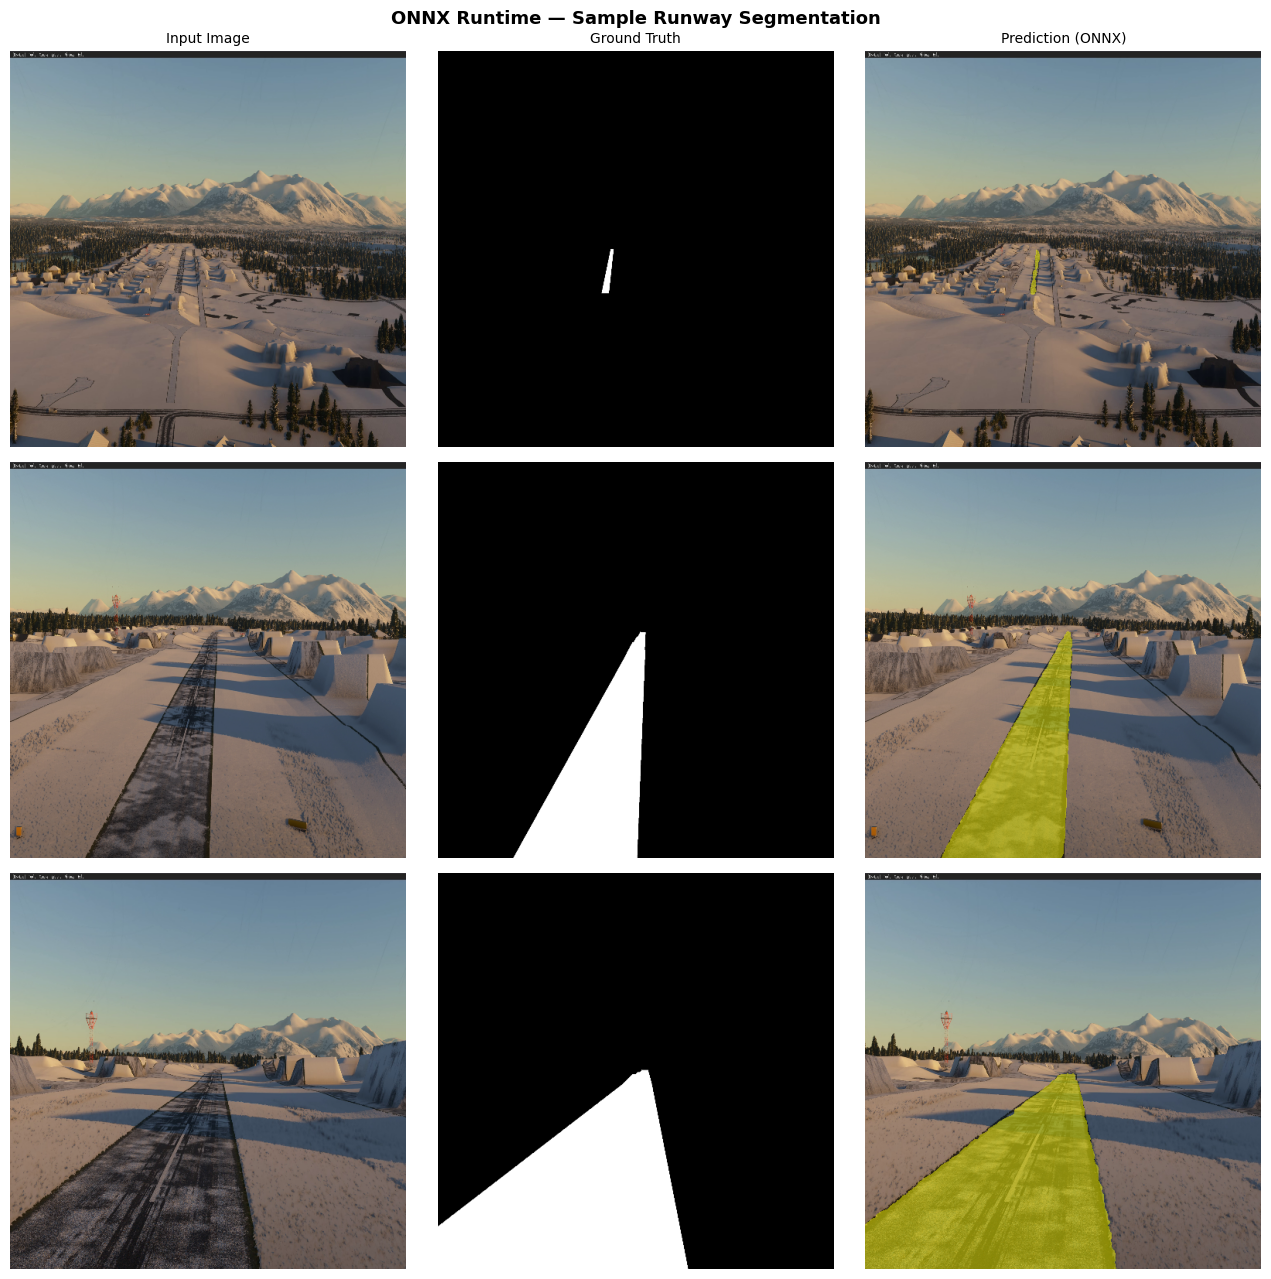

Saved → /content/drive/MyDrive/Runway_Segmentation/phase5_onnx_predictions.png


In [ ]:
# ── CELL 10: Visualize Segmentation Output ───────────────────────────────────
print("\nVisualizing sample segmentation output...")
IMAGES_DIR  = "/kaggle/input/fs2020-runway-dataset/1920x1080/1920x1080/train"
OUTPUTS_DIR = "/kaggle/input/fs2020-runway-dataset/labels/labels/areas/train_labels_1920x1080"

sample_imgs  = sorted(os.listdir(IMAGES_DIR))[:6]
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle("ONNX Runtime — Sample Runway Segmentation", fontsize=13, fontweight="bold")
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

for i, fname in enumerate(sample_imgs[:3]):
    img_bgr = cv2.imread(os.path.join(IMAGES_DIR, fname))
    msk_bgr = cv2.imread(os.path.join(OUTPUTS_DIR, fname.replace(".jpg", ".png").replace(".jpeg", ".png")),
                         cv2.IMREAD_GRAYSCALE)

    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
    img_norm = ((img_rgb.astype(np.float32) / 255.0 - MEAN) / STD).transpose(2,0,1)[None].astype(np.float32)

    logits = sess.run(None, {"input": img_norm})[0][0, 0]
    pred   = (1 / (1 + np.exp(-logits))) > 0.5

    # ── col 0: original image ──
    axes[i][0].imshow(img_rgb)
    if i == 0: axes[i][0].set_title("Input Image", fontsize=10)
    axes[i][0].axis("off")

    # ── col 1: ground truth ──
    if msk_bgr is not None:
        msk = cv2.resize(msk_bgr, (IMG_SIZE, IMG_SIZE))
        axes[i][1].imshow(msk, cmap="gray")
    axes[i][1].axis("off")
    if i == 0: axes[i][1].set_title("Ground Truth", fontsize=10)

    # ── col 2: prediction overlay ──
    overlay = img_rgb.copy()
    overlay[pred] = (overlay[pred] * 0.5 + np.array([255, 255, 0]) * 0.5).astype(np.uint8)
    axes[i][2].imshow(overlay)
    if i == 0: axes[i][2].set_title("Prediction (ONNX)", fontsize=10)
    axes[i][2].axis("off")

plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, "phase5_onnx_predictions.png")
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

In [ ]:
# ── CELL 13: How to serve on your phone ──────────────────────────────────────
import socket
hostname = socket.gethostname()
try:
    local_ip = socket.gethostbyname(hostname)
except:
    local_ip = "your-machine-ip"

print(f"""
╔══════════════════════════════════════════════════════════════╗
║  HOW TO DEMO ON YOUR PHONE                                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Download runway_seg_demo.html from Kaggle output         ║
║                                                              ║
║  2. On your laptop terminal:                                 ║
║     $ cd ~/Downloads                                         ║
║     $ python3 -m http.server 8080                            ║
║                                                              ║
║  3. Connect phone to SAME WiFi as laptop                     ║
║                                                              ║
║  4. Open phone browser → http://{local_ip}:8080/runway_seg_demo.html
║                                                              ║
║  5. Press "Start Camera" → point at any flat surface         ║
║     (The model was trained on runways but the demo works     ║
║      on any scene — for the report, screenshot the overlay)  ║
║                                                              ║
║  Alternative: Deploy free on GitHub Pages                    ║
║     → upload HTML to repo → enable Pages → share URL        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

print("Phase 5 COMPLETE")
print(f"Next: Run phase6_master_report.py to generate the final comparison tables")



╔══════════════════════════════════════════════════════════════╗
║  HOW TO DEMO ON YOUR PHONE                                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Download runway_seg_demo.html from Kaggle output         ║
║                                                              ║
║  2. On your laptop terminal:                                 ║
║     $ cd ~/Downloads                                         ║
║     $ python3 -m http.server 8080                            ║
║                                                              ║
║  3. Connect phone to SAME WiFi as laptop                     ║
║                                                              ║
║  4. Open phone browser → http://172.28.0.12:8080/runway_seg_demo.html
║                                                              ║
║  5. Press "Start Camera" → point at any flat surface         ║
║     (The model 